<a href="https://colab.research.google.com/github/Alan-Turing-33/portfolio/blob/main/alex_the_analyst_loan_default.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [16]:
from google.colab import drive
drive.mount('/content/drive')

import os

file_path = "/content/drive/MyDrive/data/Alex_the_Analyst/loan_default/"

# List files in the directory
print(f"Files in {file_path}:")
for file in os.listdir(file_path):
    print(file)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Files in /content/drive/MyDrive/data/Alex_the_Analyst/loan_default/:
borrower_profiles.csv
loan_applications.csv
loan_applications.gsheet


In [17]:
import polars as pl
import os

borrow_file_name = "borrower_profiles.csv"
loan_file_name = "loan_applications.csv"



try:
    borrow_df = pl.read_csv(file_path + borrow_file_name)
    loan_df = pl.read_csv(file_path + loan_file_name)
    print("Files loaded successfully!")
except Exception as e:
    print(f"An error occurred while reading the files: {e}")
    print("Please ensure Google Drive is mounted and the file paths are correct.")

Files loaded successfully!


In [18]:
print (f"{borrow_df.shape = }")
print (f"{loan_df.shape = }")

borrow_df.shape = (500, 11)
loan_df.shape = (601, 12)


In [19]:
borrow_df.head()

borrower_id,age,state,education_level,employment_status,years_employed,annual_income,credit_score,home_ownership,dependents,existing_monthly_debt
str,i64,str,str,str,i64,i64,i64,str,i64,i64
"""BRW-0001""",62,"""CT""","""High School""","""Self-Employed""",6,31020,596,"""Rent""",1,892
"""BRW-0002""",24,"""CO""","""High School""","""Full-Time""",4,40188,543,"""Own""",2,869
"""BRW-0003""",50,"""NC""","""Bachelor""","""Contract""",22,41014,611,"""Mortgage""",0,1806
"""BRW-0004""",43,"""TX""","""High School""","""Full-Time""",19,35036,701,"""Mortgage""",2,928
"""BRW-0005""",46,"""NY""","""High School""","""Full-Time""",18,44528,715,"""Own""",0,608


In [20]:
loan_df.head()

loan_id,borrower_id,application_date,loan_purpose,loan_amount,term_months,interest_rate,monthly_payment,dti_ratio,loan_status,days_delinquent,defaulted
str,str,str,str,f64,i64,f64,f64,f64,str,i64,i64
"""LN-00001""","""BRW-0001""","""2024-01-08""","""Vacation""",16100.0,36,13.05,542.86,55.5,"""Paid Off""",0,0
"""LN-00002""","""BRW-0001""","""2024-08-13""","""Major Purchase""",5600.0,48,14.21,153.62,40.4,"""Default""",138,1
"""LN-00003""","""BRW-0002""","""2025-06-28""","""Moving""",44700.0,36,12.37,1492.59,70.5,"""Paid Off""",0,0
"""LN-00004""","""BRW-0003""","""2025-05-18""","""Auto Loan""",9200.0,48,11.18,238.58,59.8,"""Default""",34,1
"""LN-00005""","""BRW-0004""","""2025-03-24""","""Moving""",11200.0,36,9.66,359.61,44.1,"""Current""",0,0


In [21]:
from polars import selectors as cs
borrow_df.select (cs.numeric()).describe()

statistic,age,years_employed,annual_income,credit_score,dependents,existing_monthly_debt
str,f64,f64,f64,f64,f64,f64
"""count""",500.0,500.0,500.0,500.0,500.0,500.0
"""null_count""",0.0,0.0,0.0,0.0,0.0,0.0
"""mean""",44.986,10.854,64471.484,704.952,1.356,1585.166
"""std""",13.539736,9.301706,28959.837645,97.339157,1.252358,1089.979915
"""min""",22.0,0.0,12549.0,528.0,0.0,124.0
"""25%""",33.0,3.0,43022.0,618.0,0.0,789.0
"""50%""",45.0,8.0,59422.0,709.0,1.0,1312.0
"""75%""",57.0,17.0,79780.0,794.0,2.0,2122.0
"""max""",68.0,35.0,157047.0,850.0,4.0,6130.0


In [22]:
for col in borrow_df.select (cs.string()).columns :
   print (borrow_df.group_by(col).len())

shape: (500, 2)
┌─────────────┬─────┐
│ borrower_id ┆ len │
│ ---         ┆ --- │
│ str         ┆ u32 │
╞═════════════╪═════╡
│ BRW-0067    ┆ 1   │
│ BRW-0122    ┆ 1   │
│ BRW-0147    ┆ 1   │
│ BRW-0199    ┆ 1   │
│ BRW-0068    ┆ 1   │
│ …           ┆ …   │
│ BRW-0430    ┆ 1   │
│ BRW-0224    ┆ 1   │
│ BRW-0206    ┆ 1   │
│ BRW-0495    ┆ 1   │
│ BRW-0138    ┆ 1   │
└─────────────┴─────┘
shape: (30, 2)
┌───────┬─────┐
│ state ┆ len │
│ ---   ┆ --- │
│ str   ┆ u32 │
╞═══════╪═════╡
│ NJ    ┆ 22  │
│ SC    ┆ 15  │
│ AZ    ┆ 20  │
│ OK    ┆ 13  │
│ MO    ┆ 23  │
│ …     ┆ …   │
│ TN    ┆ 15  │
│ UT    ┆ 16  │
│ CT    ┆ 12  │
│ OR    ┆ 14  │
│ IN    ┆ 20  │
└───────┴─────┘
shape: (5, 2)
┌─────────────────┬─────┐
│ education_level ┆ len │
│ ---             ┆ --- │
│ str             ┆ u32 │
╞═════════════════╪═════╡
│ Associate       ┆ 85  │
│ High School     ┆ 89  │
│ Master          ┆ 119 │
│ Doctorate       ┆ 17  │
│ Bachelor        ┆ 190 │
└─────────────────┴─────┘
shape: (5, 2)
┌────────

In [23]:
for col in loan_df.select (cs.string()).columns :
   print (loan_df.group_by(col).len())

shape: (601, 2)
┌──────────┬─────┐
│ loan_id  ┆ len │
│ ---      ┆ --- │
│ str      ┆ u32 │
╞══════════╪═════╡
│ LN-00423 ┆ 1   │
│ LN-00313 ┆ 1   │
│ LN-00470 ┆ 1   │
│ LN-00257 ┆ 1   │
│ LN-00278 ┆ 1   │
│ …        ┆ …   │
│ LN-00587 ┆ 1   │
│ LN-00006 ┆ 1   │
│ LN-00267 ┆ 1   │
│ LN-00162 ┆ 1   │
│ LN-00317 ┆ 1   │
└──────────┴─────┘
shape: (500, 2)
┌─────────────┬─────┐
│ borrower_id ┆ len │
│ ---         ┆ --- │
│ str         ┆ u32 │
╞═════════════╪═════╡
│ BRW-0456    ┆ 2   │
│ BRW-0108    ┆ 1   │
│ BRW-0158    ┆ 1   │
│ BRW-0260    ┆ 1   │
│ BRW-0074    ┆ 1   │
│ …           ┆ …   │
│ BRW-0127    ┆ 1   │
│ BRW-0004    ┆ 1   │
│ BRW-0146    ┆ 1   │
│ BRW-0181    ┆ 1   │
│ BRW-0463    ┆ 2   │
└─────────────┴─────┘
shape: (369, 2)
┌──────────────────┬─────┐
│ application_date ┆ len │
│ ---              ┆ --- │
│ str              ┆ u32 │
╞══════════════════╪═════╡
│ 2025-03-21       ┆ 1   │
│ 2025-03-02       ┆ 2   │
│ 2025-04-22       ┆ 1   │
│ 2024-04-03       ┆ 1   │
│ 2025-06-27

In [38]:
data_df = loan_df.join(borrow_df, on = "borrower_id", how = "left")

data_df = data_df.with_columns (pl.col("application_date").str.to_datetime())

data_df = data_df.drop (["loan_id", "borrower_id"])

data_df.head()


application_date,loan_purpose,loan_amount,term_months,interest_rate,monthly_payment,dti_ratio,loan_status,days_delinquent,defaulted,age,state,education_level,employment_status,years_employed,annual_income,credit_score,home_ownership,dependents,existing_monthly_debt
datetime[μs],str,f64,i64,f64,f64,f64,str,i64,i64,i64,str,str,str,i64,i64,i64,str,i64,i64
2024-01-08 00:00:00,"""Vacation""",16100.0,36,13.05,542.86,55.5,"""Paid Off""",0,0,62,"""CT""","""High School""","""Self-Employed""",6,31020,596,"""Rent""",1,892
2024-08-13 00:00:00,"""Major Purchase""",5600.0,48,14.21,153.62,40.4,"""Default""",138,1,62,"""CT""","""High School""","""Self-Employed""",6,31020,596,"""Rent""",1,892
2025-06-28 00:00:00,"""Moving""",44700.0,36,12.37,1492.59,70.5,"""Paid Off""",0,0,24,"""CO""","""High School""","""Full-Time""",4,40188,543,"""Own""",2,869
2025-05-18 00:00:00,"""Auto Loan""",9200.0,48,11.18,238.58,59.8,"""Default""",34,1,50,"""NC""","""Bachelor""","""Contract""",22,41014,611,"""Mortgage""",0,1806
2025-03-24 00:00:00,"""Moving""",11200.0,36,9.66,359.61,44.1,"""Current""",0,0,43,"""TX""","""High School""","""Full-Time""",19,35036,701,"""Mortgage""",2,928


In [64]:
pl.Config(tbl_rows=20, tbl_cols = 20, fmt_str_lengths= 12, tbl_width_chars =12  )
corr_matrix = data_df.select(cs.numeric()).corr()

print (corr_matrix)

shape: (13, 13)
┌─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┐
│ loa ┆ ter ┆ int ┆ mon ┆ dti ┆ day ┆ def ┆ age ┆ yea ┆ ann ┆ cre ┆ dep ┆ exi │
│ n_a ┆ m_m ┆ ere ┆ thl ┆ _ra ┆ s_d ┆ aul ┆ --- ┆ rs_ ┆ ual ┆ dit ┆ end ┆ sti │
│ mou ┆ ont ┆ st_ ┆ y_p ┆ tio ┆ eli ┆ ted ┆ f64 ┆ emp ┆ _in ┆ _sc ┆ ent ┆ ng_ │
│ nt  ┆ hs  ┆ rat ┆ aym ┆ --- ┆ nqu ┆ --- ┆     ┆ loy ┆ com ┆ ore ┆ s   ┆ mon │
│ --- ┆ --- ┆ …   ┆ …   ┆ f64 ┆ …   ┆ f64 ┆     ┆ …   ┆ …   ┆ --- ┆ --- ┆ …   │
│ f64 ┆ f64 ┆ --- ┆ --- ┆     ┆ --- ┆     ┆     ┆ --- ┆ --- ┆ f64 ┆ f64 ┆ --- │
│     ┆     ┆ f64 ┆ f64 ┆     ┆ f64 ┆     ┆     ┆ f64 ┆ f64 ┆     ┆     ┆ f64 │
╞═════╪═════╪═════╪═════╪═════╪═════╪═════╪═════╪═════╪═════╪═════╪═════╪═════╡
│ 1.0 ┆ -0. ┆ -0. ┆ 0.6 ┆ 0.3 ┆ -0. ┆ 0.0 ┆ -0. ┆ -0. ┆ 0.2 ┆ -0. ┆ 0.0 ┆ 0.2 │
│     ┆ 030 ┆ 002 ┆ 777 ┆ 988 ┆ 002 ┆ 181 ┆ 040 ┆ 006 ┆ 727 ┆ 003 ┆ 572 ┆ 246 │
│     ┆ 101 ┆ 563 ┆ 52  ┆ 08  ┆ 03  ┆ 16  ┆ 695 ┆ 523 ┆ 78  ┆ 482 ┆ 46  ┆ 6   │
│ -0. ┆ 1.0 ┆ -0. ┆ -0. 

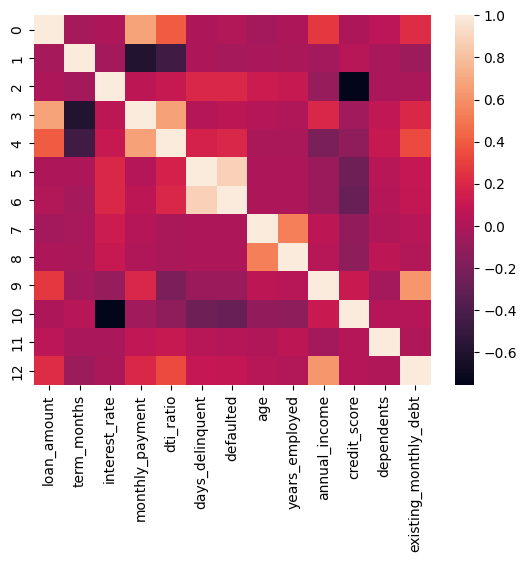

In [46]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(corr_matrix.to_pandas(), xticklabels = "auto", yticklabels = "auto")
plt.show()



In [47]:
print (data_df.columns)

['application_date', 'loan_purpose', 'loan_amount', 'term_months', 'interest_rate', 'monthly_payment', 'dti_ratio', 'loan_status', 'days_delinquent', 'defaulted', 'age', 'state', 'education_level', 'employment_status', 'years_employed', 'annual_income', 'credit_score', 'home_ownership', 'dependents', 'existing_monthly_debt']


In [50]:
print (data_df.columns)

for col in data_df.select(cs.string()).columns :
   sample = data_df.group_by(col ).agg(pl.col("defaulted").mean(), pl.col("application_date").len()).sort("defaulted")
   print (sample)

['application_date', 'loan_purpose', 'loan_amount', 'term_months', 'interest_rate', 'monthly_payment', 'dti_ratio', 'loan_status', 'days_delinquent', 'defaulted', 'age', 'state', 'education_level', 'employment_status', 'years_employed', 'annual_income', 'credit_score', 'home_ownership', 'dependents', 'existing_monthly_debt']
shape: (10, 3)
┌────────────────────┬───────────┬──────────────────┐
│ loan_purpose       ┆ defaulted ┆ application_date │
│ ---                ┆ ---       ┆ ---              │
│ str                ┆ f64       ┆ u32              │
╞════════════════════╪═══════════╪══════════════════╡
│ Medical Expenses   ┆ 0.205882  ┆ 68               │
│ Moving             ┆ 0.214286  ┆ 56               │
│ Debt Consolidation ┆ 0.215686  ┆ 51               │
│ Major Purchase     ┆ 0.220588  ┆ 68               │
│ Vacation           ┆ 0.225806  ┆ 62               │
│ Education          ┆ 0.226415  ┆ 53               │
│ Business Loan      ┆ 0.241379  ┆ 58               │
│ Auto Loa

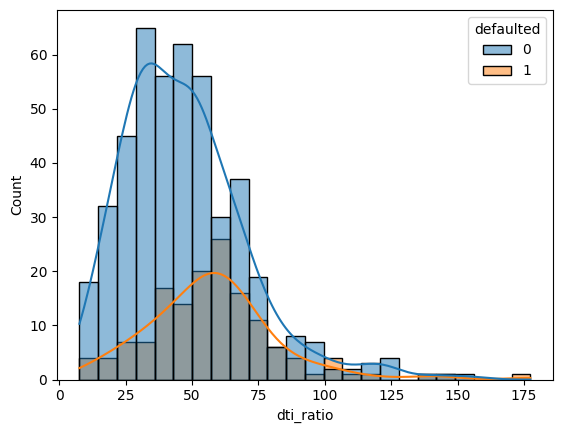

In [53]:
sns.histplot(data = data_df.to_pandas(), x = "dti_ratio", hue = "defaulted", kde=True )
plt.show()

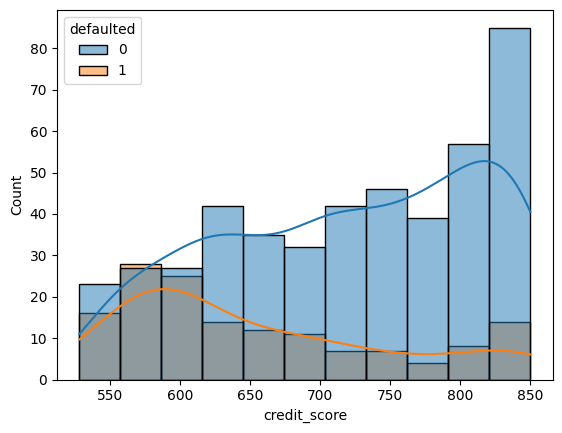

In [66]:
sns.histplot(data = data_df.to_pandas(), x = "credit_score", hue = "defaulted", kde=True )
plt.show()

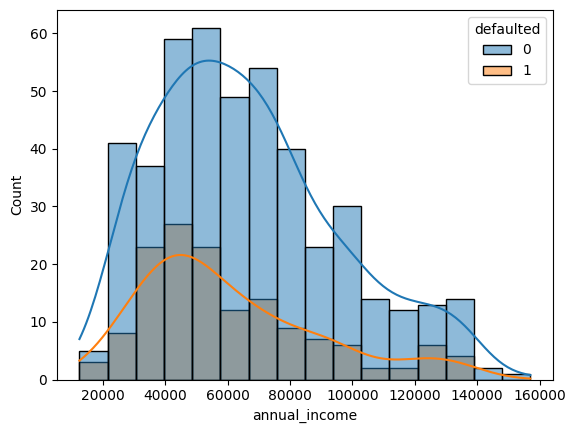

In [67]:
sns.histplot(data = data_df.to_pandas(), x = "annual_income", hue = "defaulted", kde=True )
plt.show()

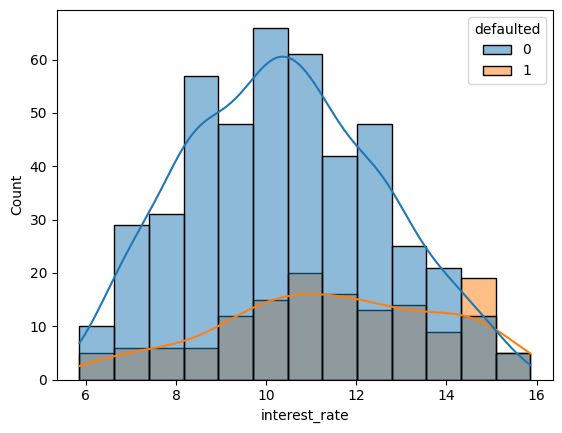

In [68]:
sns.histplot(data = data_df.to_pandas(), x = "interest_rate", hue = "defaulted", kde=True )
plt.show()

<Axes: xlabel='loan_amount', ylabel='Count'>

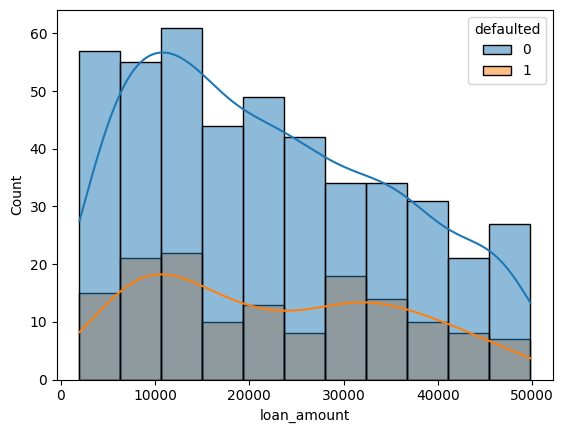

In [79]:
sns.histplot(data = data_df.to_pandas(), x = "loan_amount", hue = "defaulted", kde=True )

In [56]:
data_df.filter (pl.col("defaulted") == 0).select(cs.numeric()).describe()

statistic,loan_amount,term_months,interest_rate,monthly_payment,dti_ratio,…,age,years_employed,annual_income,credit_score,dependents,existing_monthly_debt
str,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64
"""count""",455.0,455.0,455.0,455.0,455.0,…,455.0,455.0,455.0,455.0,455.0,455.0
"""null_count""",0.0,0.0,0.0,0.0,0.0,…,0.0,0.0,0.0,0.0,0.0,0.0
"""mean""",22012.747253,36.87033,10.387868,918.050176,47.054066,…,45.18022,10.958242,66405.021978,721.665934,1.320879,1571.12967
"""std""",13240.578569,16.636523,2.126247,836.258422,23.274176,…,13.518076,9.212877,29335.562984,93.808165,1.251564,1086.503584
"""min""",2000.0,12.0,5.86,44.14,7.6,…,22.0,0.0,12549.0,528.0,0.0,124.0
"""25%""",10900.0,24.0,8.7,359.61,30.9,…,34.0,3.0,43591.0,641.0,0.0,775.0
"""50%""",20400.0,36.0,10.29,668.55,44.6,…,45.0,8.0,62522.0,730.0,1.0,1282.0
"""75%""",32400.0,48.0,12.0,1161.52,58.8,…,57.0,17.0,83163.0,806.0,2.0,2178.0
"""max""",49800.0,60.0,15.28,4262.69,155.3,…,68.0,35.0,157047.0,850.0,4.0,6130.0


In [65]:
data_df.filter (pl.col("defaulted") == 1).select(cs.numeric()).describe()

statistic,loan_amount,term_months,interest_rate,monthly_payment,dti_ratio,days_delinquent,defaulted,age,years_employed,annual_income,credit_score,dependents,existing_monthly_debt
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""count""",146.0,146.0,146.0,146.0,146.0,146.0,146.0,146.0,146.0,146.0,146.0,146.0,146.0
"""null_count""",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
"""mean""",22570.547945,35.506849,11.431233,1042.726712,57.866438,101.328767,1.0,44.986301,10.80137,60853.952055,656.130137,1.39726,1789.527397
"""std""",13172.443377,17.708072,2.44637,945.697642,24.91819,43.806173,0.0,14.216545,9.80965,28538.223809,95.338472,1.234445,1226.504982
"""min""",2400.0,12.0,6.03,109.04,9.8,31.0,1.0,22.0,0.0,17078.0,531.0,0.0,133.0
"""25%""",10800.0,12.0,9.76,366.36,41.4,61.0,1.0,33.0,2.0,41014.0,582.0,0.0,892.0
"""50%""",20400.0,36.0,11.5,774.09,57.8,105.0,1.0,45.0,8.0,53099.0,619.0,1.0,1629.0
"""75%""",33300.0,48.0,13.39,1258.37,69.7,135.0,1.0,57.0,17.0,74343.0,725.0,2.0,2365.0
"""max""",49700.0,60.0,15.86,4247.83,177.4,180.0,1.0,68.0,35.0,137015.0,850.0,4.0,6096.0


shape: (10, 2)
┌─────┬─────┐
│ loa ┆ def │
│ n_b ┆ aul │
│ ins ┆ ted │
│ --- ┆ --- │
│ cat ┆ f64 │
╞═════╪═════╡
│ (-i ┆ 0.1 │
│ nf, ┆ 935 │
│ 600 ┆ 48  │
│ 0]  ┆     │
│ (12 ┆ 0.2 │
│ 500 ┆ 5   │
│ ,   ┆     │
│ 156 ┆     │
│ 0…  ┆     │
│ (15 ┆ 0.2 │
│ 600 ┆ 5   │
│ ,   ┆     │
│ 204 ┆     │
│ 0…  ┆     │
│ (20 ┆ 0.1 │
│ 400 ┆ 525 │
│ ,   ┆ 42  │
│ 251 ┆     │
│ 0…  ┆     │
│ (25 ┆ 0.2 │
│ 100 ┆ 5   │
│ ,   ┆     │
│ 301 ┆     │
│ 0…  ┆     │
│ (30 ┆ 0.3 │
│ 100 ┆     │
│ ,   ┆     │
│ 353 ┆     │
│ 0…  ┆     │
│ (35 ┆ 0.2 │
│ 300 ┆ 950 │
│ ,   ┆ 82  │
│ 421 ┆     │
│ 0…  ┆     │
│ (42 ┆ 0.2 │
│ 100 ┆ 033 │
│ ,   ┆ 9   │
│ inf ┆     │
│ ]   ┆     │
│ (60 ┆ 0.2 │
│ 00, ┆ 786 │
│ 910 ┆ 89  │
│ 0]  ┆     │
│ (91 ┆ 0.2 │
│ 00, ┆ 542 │
│ 125 ┆ 37  │
│ 00… ┆     │
└─────┴─────┘


<Axes: xlabel='loan_bins', ylabel='defaulted'>

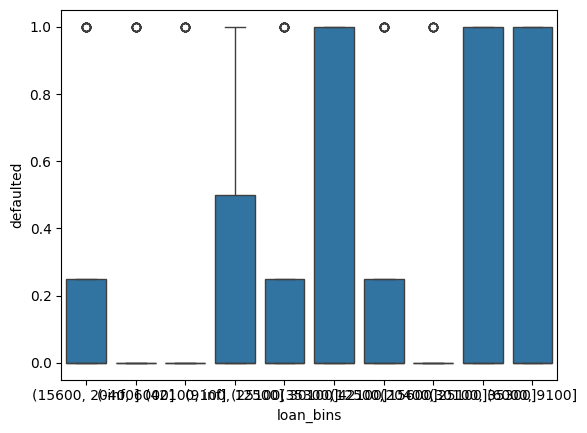

In [97]:
#data_df = data_df.with_columns (pl.col("loan_amount").qcut([0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9], labels = ["0.1", "0.2", "0.3", "0.4", "0.5", "0.6", "0.7", "0.8", "0.9", "1.0"]).alias ("loan_bins"))
data_df = data_df.with_columns (pl.col("loan_amount").qcut(10 ).alias ("loan_bins"))

result = data_df.group_by ("loan_bins").agg(pl.col("defaulted").mean()).sort("loan_bins")
print (result)
sns.boxplot(data = data_df.to_pandas(), x = "loan_bins", y = "defaulted")


In [96]:
data_df.filter ((pl.col("credit_score") > 625 ) &
                 (pl.col("interest_rate") < 13.5) &
                 (pl.col("dti_ratio") < 60)
#                 (pl.col("loan_amount") < 32000)
                 ).select(cs.numeric()).describe()


statistic,loan_amount,term_months,interest_rate,monthly_payment,dti_ratio,days_delinquent,defaulted,age,years_employed,annual_income,credit_score,dependents,existing_monthly_debt
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""count""",316.0,316.0,316.0,316.0,316.0,316.0,316.0,316.0,316.0,316.0,316.0,316.0,316.0
"""null_count""",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
"""mean""",19677.848101,40.78481,9.742437,655.845886,37.138608,15.060127,0.129747,44.433544,10.544304,68978.243671,757.006329,1.341772,1427.227848
"""std""",12741.548701,15.503135,1.742836,517.433886,13.091658,35.557682,0.336558,13.686235,8.592426,31260.719987,67.532238,1.238392,1069.398863
"""min""",2100.0,12.0,5.99,51.68,7.6,0.0,0.0,22.0,0.0,16498.0,626.0,0.0,124.0
"""25%""",8800.0,24.0,8.42,283.61,27.5,0.0,0.0,33.0,3.0,44951.0,700.0,0.0,640.0
"""50%""",17200.0,48.0,9.85,534.66,37.6,0.0,0.0,44.0,8.0,62885.0,761.0,1.0,1139.0
"""75%""",28600.0,48.0,10.91,876.47,48.3,15.0,0.0,56.0,16.0,88548.0,816.0,2.0,1915.0
"""max""",49800.0,60.0,13.45,3450.5,59.8,168.0,1.0,68.0,35.0,157047.0,850.0,4.0,6130.0


In [ ]:
df_data [df_data.duplicated(keep=False)]

In [ ]:
df_data.drop_duplicates(inplace = True)
df_data.reset_index (drop = True, inplace = True)
